<a href="https://colab.research.google.com/github/PMUSKET2/Critical_Infrastructure_LLM/blob/main/notebooks/Simple_Machine_learning_training_example_with_CFID_descriptors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Table of contents

1. Loading CFID-3D dataset from figshare
2. Making pandas dataframe
3. Properties available, keys
4. Preparing training and target data
5. Simple regression traiing on 500 samples for formation energies
6. Visualizing training results

In [1]:
!pip install jarvis-tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 30.2 MB/s eta 0:00:00


In [2]:
# !pip install jarvis-tools, and restart runtime in the notebook if you haven't installed it yet
from jarvis.db.figshare import data
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

cfid_3d = data('cfid_3d')

Obtaining 3D dataset 55k ...
Reference:https://www.nature.com/articles/s41524-020-00440-1
Other versions:https://doi.org/10.6084/m9.figshare.6815699


100%|██████████| 446M/446M [00:15<00:00, 28.0MiB/s]


Loading the zipfile...
Loading completed.


In [3]:
len(cfid_3d)

55723

In [4]:
typical_data_ranges = {'formation_energy_peratom': [-5, 5], 'optb88vdw_bandgap': [0, 10], 'mbj_bandgap': [0, 10], 'bulk_modulus_kv': [0, 250], 'shear_modulus_gv': [0, 250], 'epsx': [0, 60], 'epsy': [0, 60], 'epsz': [0, 60], 'mepsx': [0, 60], 'mepsy': [0, 60], 'mepsz': [0, 60], 'n-Seebeck': [-600, 10], 'n-powerfact': [0, 5000], 'p-Seebeck': [-10, 600], 'p-powerfact': [0, 5000], 'slme': [0, 40], 'spillage': [0, 4], 'encut': [0, 2000], 'kpoint_length_unit': [0, 200], 'dfpt_piezo_max_dielectric': [0, 100], 'dfpt_piezo_max_dij': [0, 3000], 'dfpt_piezo_max_eij': [0, 10], 'ehull': [0, 1], 'electron_avg_effective_masses_300K': [0, 3], 'hole_avg_effective_masses_300K': [0, 3], 'exfoliation_energy': [0, 1000], 'magmom_oszicar': [0, 10], 'max_ir_mode': [0, 4000], 'total_energy_per_atom': [-10, 3]}

In [5]:
typical_data_ranges

{'formation_energy_peratom': [-5, 5],
 'optb88vdw_bandgap': [0, 10],
 'mbj_bandgap': [0, 10],
 'bulk_modulus_kv': [0, 250],
 'shear_modulus_gv': [0, 250],
 'epsx': [0, 60],
 'epsy': [0, 60],
 'epsz': [0, 60],
 'mepsx': [0, 60],
 'mepsy': [0, 60],
 'mepsz': [0, 60],
 'n-Seebeck': [-600, 10],
 'n-powerfact': [0, 5000],
 'p-Seebeck': [-10, 600],
 'p-powerfact': [0, 5000],
 'slme': [0, 40],
 'spillage': [0, 4],
 'encut': [0, 2000],
 'kpoint_length_unit': [0, 200],
 'dfpt_piezo_max_dielectric': [0, 100],
 'dfpt_piezo_max_dij': [0, 3000],
 'dfpt_piezo_max_eij': [0, 10],
 'ehull': [0, 1],
 'electron_avg_effective_masses_300K': [0, 3],
 'hole_avg_effective_masses_300K': [0, 3],
 'exfoliation_energy': [0, 1000],
 'magmom_oszicar': [0, 10],
 'max_ir_mode': [0, 4000],
 'total_energy_per_atom': [-10, 3]}

In [6]:
df=pd.DataFrame(cfid_3d)

In [7]:
df.columns

Index(['jid', 'spg_number', 'spg_symbol', 'formula',
       'formation_energy_peratom', 'func', 'optb88vdw_bandgap', 'atoms',
       'slme', 'magmom_oszicar', 'spillage', 'elastic_tensor',
       'effective_masses_300K', 'kpoint_length_unit', 'maxdiff_mesh',
       'maxdiff_bz', 'encut', 'optb88vdw_total_energy', 'epsx', 'epsy', 'epsz',
       'mepsx', 'mepsy', 'mepsz', 'modes', 'magmom_outcar', 'max_efg',
       'avg_elec_mass', 'avg_hole_mass', 'icsd', 'dfpt_piezo_max_eij',
       'dfpt_piezo_max_dij', 'dfpt_piezo_max_dielectric',
       'dfpt_piezo_max_dielectric_electronic',
       'dfpt_piezo_max_dielectric_ionic', 'max_ir_mode', 'min_ir_mode',
       'n-Seebeck', 'p-Seebeck', 'n-powerfact', 'p-powerfact', 'ncond',
       'pcond', 'nkappa', 'pkappa', 'ehull', 'dimensionality', 'efg',
       'xml_data_link', 'typ', 'exfoliation_energy', 'spg', 'crys', 'density',
       'poisson', 'raw_files', 'nat', 'bulk_modulus_kv', 'shear_modulus_gv',
       'mbj_bandgap', 'hse_gap', 'reference'

In [8]:
def get_ml_data(dataframe='', ml_property='formation_energy_peratom'):
    x = []
    y = []
    jid = []
    df2 = dataframe[['desc','jid',ml_property]].replace('na',np.nan).dropna()
    for ii,i in df2.iterrows():
        if len(i['desc']) ==1557 and float(i[ml_property])!=float('inf') and i[ml_property]!='na' \
            and float(i[ml_property])<typical_data_ranges[ml_property][1] \
            and float(i[ml_property])>typical_data_ranges[ml_property][0] :
            x.append(i['desc'])
            y.append(i[ml_property])
            jid.append(i['jid'])
    return np.array(x,dtype='float'),np.array(y,dtype='float'),jid

In [9]:
ml_property= 'formation_energy_peratom' #'bulk_modulus_kv'
x, y, jids = get_ml_data(dataframe=df, ml_property='formation_energy_peratom')

In [10]:
# 90 %-10 % train-test split
X_train, X_test, y_train, y_test,jid_train,jid_test = train_test_split(x, y,jids, random_state=1, test_size=0.1)
print (len(X_train), len(X_test))

50150 5573


In [11]:
#Let's take 500 samples only for a quick training
# For more accurate models, higher number of points and hyper-parameter optimization etc. is needed
X1=X_train[0:500]
Y1=y_train[0:500]
X2=X_test[0:500]
Y2=y_test[0:500]
print (X1.shape)

(500, 1557)


In [12]:
#Typical hyperparameter optimized parameters in LightGBM:
#"n_estimators": 1170,
#"learning_rate": 0.15375236057119931,
#"num_leaves": 273,

In [13]:
# GB regressor with default parameters
model = GradientBoostingRegressor()
model.fit(X1,Y1)

GradientBoostingRegressor()

In [14]:
# predict on 10% held set which was not used during training
pred=model.predict(X2)

In [15]:
def regr_scores(pred, test):

    """
   Generic regresion scores
   Args:
       pred: predicted values
       test: held data for testing
   Returns:
        info: with metrics
   """

    rmse = np.sqrt(mean_squared_error(test, pred))
    r2 = r2_score(test, pred)
    mae = mean_absolute_error(test, pred)
    info = {}
    info["mae"] = mae
    info["rmse"] = rmse
    info["r2"] = r2
    info["test"] = test
    info["pred"] = pred
    return info

Text(0, 0.5, 'ML-Formation energy (eV/atom)')

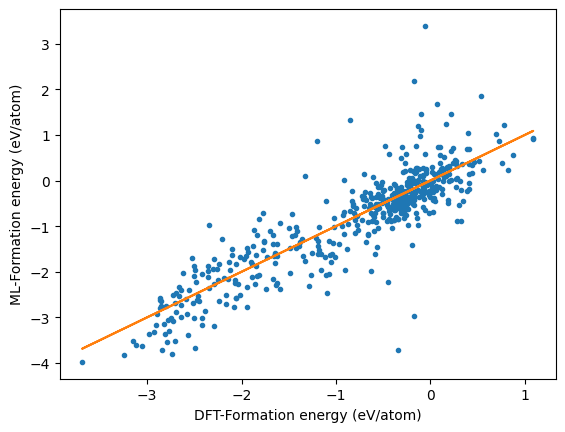

In [16]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
reg_sc=regr_scores(Y2,pred)
plt.plot(reg_sc['test'],reg_sc['pred'],'.')
plt.plot(reg_sc['test'],reg_sc['test'])
plt.xlabel('DFT-Formation energy (eV/atom)')
plt.ylabel('ML-Formation energy (eV/atom)')

In [17]:
reg_sc

{'mae': 0.37298325317033887,
 'rmse': np.float64(0.5475466706614437),
 'r2': 0.6799014051160028,
 'test': array([-7.86728575e-01, -4.00882978e-01, -7.72178134e-02,  2.39881477e-01,
        -8.91561726e-02,  3.87007289e-02, -3.48572840e-01, -2.42081901e+00,
        -1.83442995e+00,  4.07629563e-01, -2.23408630e+00,  5.20739230e-02,
        -2.16370789e+00,  3.22915817e-01, -2.49499321e-01, -3.53480688e-01,
        -2.78310359e-01, -4.03741412e-01,  1.64870034e-02, -4.50413726e-01,
        -8.06756471e-01, -2.50871246e+00, -2.06234939e+00, -7.73724783e-01,
        -5.32976250e-01, -7.67295232e-01, -2.80514088e+00, -5.17765500e-01,
        -1.38141703e+00,  5.15400947e-01, -3.07334128e-01,  4.35580471e-01,
        -2.34879467e+00, -1.18549350e+00, -2.50294350e+00, -5.25529596e-02,
        -1.65156409e+00, -3.57545945e-01, -5.43154324e-01,  3.03026955e-01,
        -9.13273362e-01, -1.46607815e+00, -1.87986164e-01, -2.48163657e+00,
        -4.22415992e-01, -2.72544712e+00, -5.80661430e-01, 

Obtaining 3D dataset 55k ...
Reference:https://www.nature.com/articles/s41524-020-00440-1


100%|██████████| 31.9M/31.9M [00:01<00:00, 16.5MiB/s]


Loading the zipfile...
Loading completed.
Element-fraction feature shape: (55723, 103)
Training shape: (500, 103)
Element-fraction MAE  : 0.4571
Element-fraction RMSE : 0.6518
Element-fraction R²   : 0.4322


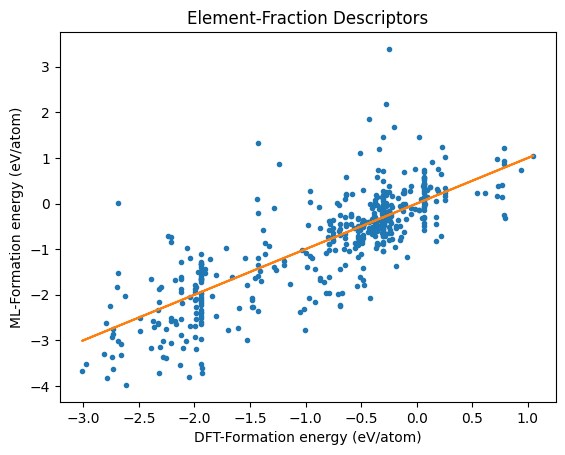

In [18]:
# ============================================================
# ELEMENT-FRACTION DESCRIPTOR EXAMPLE
# ============================================================
# Element fractions represent each material as a 103-dim vector
# where entry i = the fraction of element i in the composition.
# This is a much simpler featurization than the full 1557-dim CFID.
# ============================================================

from jarvis.core.composition import Composition

# --- Step 1: Build a jid -> formula lookup from dft_3d_2021 ---
# (same vintage as cfid_3d; shares the same jids)
dft_3d = data('dft_3d_2021')
jid_to_formula = {entry['jid']: entry['formula'] for entry in dft_3d}

# --- Step 2: Build element-fraction feature matrix ---
def get_ef_ml_data(dataframe='', ml_property='formation_energy_peratom'):
    x_ef = []
    y_ef = []
    jids_ef = []
    df2 = dataframe[['jid', ml_property]].replace('na', np.nan).dropna()
    for ii, i in df2.iterrows():
        jid = i['jid']
        if jid not in jid_to_formula:
            continue
        formula = jid_to_formula[jid]
        try:
            feat = Composition.from_string(formula).atomic_fraction_array  # 103-dim
        except Exception:
            continue
        val = i[ml_property]
        if (val != float('inf') and val != 'na'
                and float(val) < typical_data_ranges[ml_property][1]
                and float(val) > typical_data_ranges[ml_property][0]):
            x_ef.append(feat)
            y_ef.append(val)
            jids_ef.append(jid)
    return np.array(x_ef, dtype='float'), np.array(y_ef, dtype='float'), jids_ef

x_ef, y_ef, jids_ef = get_ef_ml_data(dataframe=df, ml_property='formation_energy_peratom')
print('Element-fraction feature shape:', x_ef.shape)   # expect (N, 103)

# --- Step 3: Train/test split (same 90/10 split) ---
X_train_ef, X_test_ef, y_train_ef, y_test_ef, jid_train_ef, jid_test_ef = \
    train_test_split(x_ef, y_ef, jids_ef, random_state=1, test_size=0.1)

# --- Step 4: Subset to 500 samples for quick training ---
X1_ef = X_train_ef[:500]
Y1_ef = y_train_ef[:500]
X2_ef = X_test_ef[:500]
Y2_ef = y_test_ef[:500]
print('Training shape:', X1_ef.shape)  # expect (500, 103)

# --- Step 5: Train GradientBoostingRegressor (same defaults) ---
model_ef = GradientBoostingRegressor()
model_ef.fit(X1_ef, Y1_ef)

# --- Step 6: Predict on held-out test set ---
pred_ef = model_ef.predict(X2_ef)

# --- Step 7: Evaluate and plot ---
reg_sc_ef = regr_scores(Y2_ef, pred_ef)
print('Element-fraction MAE  :', round(reg_sc_ef['mae'], 4))
print('Element-fraction RMSE :', round(reg_sc_ef['rmse'], 4))
print('Element-fraction R²   :', round(reg_sc_ef['r2'], 4))

plt.figure()
plt.plot(reg_sc_ef['test'], reg_sc_ef['pred'], '.')
plt.plot(reg_sc_ef['test'], reg_sc_ef['test'])
plt.xlabel('DFT-Formation energy (eV/atom)')
plt.ylabel('ML-Formation energy (eV/atom)')
plt.title('Element-Fraction Descriptors')
plt.show()

In [19]:
import pandas as pd

# Create a dataframe with the test results
results_df = pd.DataFrame({
    'jid': jids_ef[:500],
    'dft_formation_energy': Y2_ef,
    'ml_prediction': pred_ef,
    'absolute_error': abs(Y2_ef - pred_ef)
})

# Add summary metrics as a separate sheet
metrics_df = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'value': [reg_sc_ef['mae'], reg_sc_ef['rmse'], reg_sc_ef['r2']]
})

# Save to Excel with two sheets
with pd.ExcelWriter('element_fraction_results.xlsx', engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='Predictions', index=False)
    metrics_df.to_excel(writer, sheet_name='Metrics', index=False)

print("Saved: element_fraction_results.xlsx")

Saved: element_fraction_results.xlsx
